# Tutorial 11, Part 2: iLQR

## 1. Introduction

First, we set up our PendulumPlant instance:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import random 
import sympy as smp
import time
import os

%matplotlib inline

from IPython.display import HTML

from util.pendulum_plant import PendulumPlant, plot_timeseries
from util.lqr import lqr, dlqr
from util.utilities_iLQR import check_type

In [2]:
mass = 0.06      # mass at the end of the pendulum [kg]
length = 0.1    # length of the rod [m]
damping = 0.0004   # viscious friction [kg m/s]
gravity = 9.81  # gravity [kg m²/s]
inertia = mass*length*length   # inertia of the pendulum [kg m²]
coulomb_fric = 0.0   # Coulomb friction coefficient [-]
torque_limit = np.inf  # torque limit of the motor, here we assume the motor can produce any torque
dt = 0.010            # time step size for iLQR (not simulations) [s]

pendulum = PendulumPlant(mass=mass,
                         length=length,
                         damping=damping,
                         gravity=gravity,
                         inertia=inertia,
                         torque_limit=torque_limit) 

In order to simulate and animate a motion of the pendulum you can call the simulate_and_animate class method. The arguments are:

    - t0: the initial time
    - y0: the initial state
    - tf: the final time
    - dt: the integration timestep
    - controller: controller object providing torques for the motor (introduced later)
    - integrator: the integration method. options are "euler" and "runge_kutta"
    
The method returns the trajectory split in to time (T), state (X) and torques (U) as well as an animation object.

**Note:** If you do not need the animation you can also call the method *simulate* with the same parameters. The method returns T, X, U but no animation object. Making an animation **takes some time**. 

## 2. Iterative Linear Quadratic Regulator

With underactuated systems, traditional reactive controllers are sometimes unable to achieve desirable outcomes. One way to overcome this is through *trajectory optimisation*: rather than reacting to the current state alone, we plan an entire sequence of control inputs ahead of time by exploiting our knowledge of the system's dynamics.

An **iterative Linear Quadratic Regulator (iLQR)** achieves this by repeatedly solving a locally-linear approximation of the optimal control problem. Starting from an initial trajectory, the algorithm linearises the (generally nonlinear) dynamics around the current trajectory, solves the resulting LQR problem to obtain an improved control law, simulates the system forward to get a new trajectory, and repeats until convergence. The result is a locally-optimal trajectory tailored to the cost function we specify.

### 2.1. The iLQR Problem

The goal is to find a sequence of control inputs $u_0, \ldots, u_{N-1}$ that minimises a total cost over a finite horizon of $N$ steps:

$$\min_{u_0,\ldots,u_{N-1}} \; \ell_f(x_N) + \sum_{n=0}^{N-1} \ell(x_n, u_n)$$

subject to the discrete-time dynamics:

$$x_{n+1} = f(x_n, u_n) \quad \forall\, n \in [0, N-1]$$

where:
- $x_n \in \mathbb{R}^{n_x}$ is the state at step $n$,
- $u_n \in \mathbb{R}^{n_u}$ is the control input at step $n$,
- $f$ is the (potentially nonlinear) dynamics function.

Besides, the cost comprises two distinct terms:
- $\ell(x_n, u_n)$ is called the *stage cost*: This is the penalty incurred at every step except the last.
- $\ell_f(x_N)$ is called the *terminal cost*: This is the penalty on the final state. Since no further control will be applied, it only depends on $x_N$.

The initial state $x_0$ is given, and all following states are a function of the state and control input at the previous instant.


### 2.2. iLQR calculator class

The first step in our procedure is to define a class which we will call to solve the iLQR problem. Here, we will define the steps we take to obtain the optimal trajectory, which we will later enforce with another controller.

Initially, we define the following member functions:

- **\_\_init\_\_**: Class constructor, initializes symbolic varaibles *x_sym* and *u_sym*.
- **set_start**: Allows us to set an initial state.
- **set_discrete_dynamics**: Allows us to set the dynamics of the system. The dynamics must be already in discrete form, i.e., the inputs are the previous state and control and the output the new state.
- **set_stage_cost**: Allows us to define a cost function for the duration of the motion (except for the final state).
- **set_final_cost**: Allows us to define a cost function for the final state.
- **cost_trj**: Calculates the cost associated to the provided trajectory.

In [3]:
# The following is adapted from DFKI's iLQR code
# Large parts taken from `Russ Tedrake <https://github.com/RussTedrake/underactuated>`_.

class iLQR_Calculator():
    '''
    Class to calculate an optimal trajectory with an iterative
    linear quadratic regulator (iLQR). This implementation uses sympy.
    '''
    def __init__(self, n_x=2, n_u=1):
        """
        Class to calculate an optimal trajectory with an iterative
        linear quadratic regulator (iLQR). This implementation uses sympy.

        Parameters
        ----------
        n_x : int, default=2
            The size of the state space.
        n_u : int, default=1
            The size of the control space.
        """
        self.n_x = n_x
        self.n_u = n_u

        self.x_sym = smp.symbols("x:"+str(self.n_x))
        self.u_sym = smp.symbols("u:"+str(self.n_u))

    def set_start(self, x0):
        """
        Set the start state for the trajectory.

        Parameters
        ----------
        x0 : array-like
            the start state. Should have the shape of (n_x,)
        """
        self.x0 = x0

    def set_discrete_dynamics(self, dynamics_func):
        '''
        Sets the dynamics function for the iLQR calculation.

        Parameters
        ----------
        danamics_func : function
            dynamics_func should be a function with inputs (x, u) and output xd
        '''
        self.discrete_dynamics = dynamics_func

    def set_stage_cost(self, stage_cost_func):
        '''
        Set the stage cost (running cost) for the ilqr optimization.

        Parameters
        ----------
        stage_cost_func : function
            stage_cost_func should be a function with inputs (x, u)
            and output cost
        '''
        self.stage_cost = stage_cost_func

    def set_final_cost(self, final_cost_func):
        '''
        Set the final cost for the ilqr optimization.

        Parameters
        ----------
        final_cost_func : function
            final_cost_func should be a function with inputs x
            and output cost
        '''
        self.final_cost = final_cost_func

    def cost_trj(self, x_trj, u_trj):
        total = 0.0
        ln = 0.0
        N = x_trj.shape[0]
        for i in range(len(x_trj)-1):
            ln = ln + self.stage_cost(x_trj[i, :], u_trj[i, :]) / N
        lf = self.final_cost(x_trj[i+1, :])
        total = ln + lf
        return total

### 2.3. System Dynamics

We are dealing again with our simple pendulum, whose dynamics are nonlinear. The state vector is $x = [\theta,\, \dot\theta]^T$, where $\theta$ is the angle and $\dot\theta$ is the angular velocity. The control input $u$ is the torque applied at the base.

The equation of motion is:

$$\ddot{\theta} = \frac{u - mgl\sin\theta - b\dot{\theta}}{I}$$

where $m$ is the mass, $g$ denotes gravitation, $l$ is the pendulum length, $b$ is a viscous damping coefficient, and $I \approx ml^2$ is the moment of inertia about the base (approximated using the parallel axis theorem).

It is important to emphasize that now we are dealing with the _full nonlinear_ system. That means the nonlinear $\sin\theta$ term is considered and we do not limit ourself to a linearization around a setpoint any more.  In state-space form the continuous dynamics are:

$$\dot{x} = f_c(x, u) = \begin{bmatrix} \dot\theta \\ \dfrac{u - mgl\sin\theta - b\dot\theta}{I} \end{bmatrix}$$

This is different from the linear form $\dot{x} = Ax + Bu$ used in standard LQR, and also the reason why we are using iLQR in the first place.

In [4]:
def pendulum_continuous_dynamics(x, u):
    md = check_type(x)

    m = mass
    l = length
    b = damping
    cf = coulomb_fric
    g = gravity
    inertia = m*l*l
    
    pos = x[0]
    vel = x[1]
    if md == smp:
        accn = (u[0] - m * g * l * md.sin(pos) - b * vel -
                cf*md.atan(1e8*vel)*2/np.pi) / inertia
    elif md == np:
        accn = (u[0] - m * g * l * md.sin(pos) - b * vel -
                cf*md.arctan(1e8*vel)*2/np.pi) / inertia
    xd = np.array([vel, accn])
    return xd

To obtain a discrete version of the dynamics, we may apply one of the many explicit integration schemes. Two popular options are the forward Euler scheme and the fourth-order Runge Kutta scheme.

In [5]:
def pendulum_discrete_dynamics_euler(x, u):
    md = check_type(x)

    x_d = pendulum_continuous_dynamics(x, u)
    x_next = x + x_d*dt
    if md == smp:
        x_next = tuple(x_next)
    return x_next

def pendulum_discrete_dynamics_RK4(x, u):
    md = check_type(x)
    
    k1 = pendulum_continuous_dynamics(x,u)
    k2 = pendulum_continuous_dynamics(x + 0.5*dt*k1,u)
    k3 = pendulum_continuous_dynamics(x + 0.5*dt*k2,u)
    k4 = pendulum_continuous_dynamics(x + dt*k3,u)
    x_d = (k1 + 2 * (k2 + k3) + k4) / 6.0
    x_next = x + x_d*dt
    if md == smp:
        x_next = tuple(x_next)
    return x_next

We can roll out the trajectory, based on planned inputs and an initial state by forward integration. This function is not used if initial guesses of both the states as well as the control inputs are provided to the calculator.

In [6]:
def rollout(self, u_trj):
    x_trj = np.zeros((u_trj.shape[0]+1, self.x0.shape[0]))
    x = self.x0
    i = 0
    x_trj[i, :] = x
    for u in u_trj:
        i = i+1
        x = self.discrete_dynamics(x, u)
        x_trj[i, :] = x
    return x_trj

iLQR_Calculator.rollout = rollout

### 2.4. Cost Function

Our goal is to get the pendulum to reach its unstable equilibrium point (swing up) within a fixed time horizon of 10 seconds. We also want it to have as low a velocity as possible at the moment it reaches that point. Lastly, we want to minimize the torque given to the pendulum during the motion.

This gives the following cost functions:

$$\ell(x_n, u_n) = C_u\, u_n^2$$

$$\ell_f(x_N) = C_p\,(\theta_N - \theta_\text{goal})^2 + C_v\,(\dot\theta_N - \dot\theta_\text{goal})^2$$

where $C_u > 0$, $C_p > 0$, and $C_v > 0$ are scalar weights on control effort, final position error, and final velocity error respectively.

**Both $\ell$ and $\ell_f$ are quadratic in their arguments, which is required for the iLQR derivation below.**
% TODO

In [7]:
def pendulum_swingup_stage_cost(x, u):
    goal=[np.pi, 0]
    Cu=3
    Cp=0.00002
    Cv=0.000004
    Cen=0.0
    m=mass
    l=length
    b=damping
    cf=coulomb_fric
    g=gravity
    
    md = check_type(x)

    eps = 1e-6
    c_pos = (x[0] - goal[0] + eps)**2.0
    c_vel = (x[1] - goal[1] + eps)**2.0
    c_control = u[0]**2.0
    #c_control = u**2.0
    en_g = 0.5*m*(l*goal[1])**2.0 + m*g*l*(1.0-md.cos(goal[0]))
    en = 0.5*m*(l*x[1])**2.0 + m*g*l*(1.0-md.cos(x[0]))
    c_en = (en-en_g+eps)**2.0
    return Cu*c_control + Cp*c_pos + Cv*c_vel + Cen*c_en

def pendulum_swingup_final_cost(x):
    goal=[np.pi, 0]
    Cp=0.1
    Cv=0.02
    Cen=0.0
    m=mass
    l=length
    b=damping
    cf=coulomb_fric
    g=gravity
    
    md = check_type(x)

    eps = 1e-6
    c_pos = (x[0] - goal[0] + eps)**2.0
    c_vel = (x[1] - goal[1] + eps)**2.0
    en_g = 0.5*m*(l*goal[1])**2.0 + m*g*l*(1.0-md.cos(goal[0]))
    en = 0.5*m*(l*x[1])**2.0 + m*g*l*(1.0-md.cos(x[0]))
    c_en = (en-en_g+eps)**2.0
    return Cp*c_pos + Cv*c_vel + Cen*c_en   



### 2.5. Bellman's Principle of Optimality and the iLQR Derivation

#### 2.5.1. Bellman's Principle

Bellman's principle of optimality is the foundation of the iLQR solution. It states:

> "An optimal policy has the property that whatever the initial state and initial decision are, the remaining decisions must constitute an optimal policy with regard to the state resulting from the first decision." (R. Bellman, 1957, p. 83)

In practical terms, this means we can solve the full optimisation problem by working backwards through time, solving a one-step subproblem at each instant. We define the **cost-to-go** $V(x_n)$ as the minimum total cost achievable from state $x_n$ onwards. Bellman's principle gives us the recursion:

$$V(x_n) = \min_{u_n} \left[\, \ell(x_n,\, u_n) + V(x_{n+1}) \,\right]$$

with boundary condition $V(x_N) = \ell_f(x_N)$, which depends only on the terminal state.

#### 2.5.2. Linearisation Around a Nominal Trajectory

For a nonlinear system, the recursion above cannot be solved exactly. iLQR approximates it by linearising around a **nominal trajectory** $\bar{x}_0, \ldots, \bar{x}_N$, $\bar{u}_0, \ldots, \bar{u}_{N-1}$. We define small deviations from this trajectory:

$$\delta x_n = x_n - \bar{x}_n, \qquad \delta u_n = u_n - \bar{u}_n$$

so that the true state and control are $x_n = \bar{x}_n + \delta x_n$ and $u_n = \bar{u}_n + \delta u_n$.

In the following, we use this formulation to decompose the cost function into terms as a consequence of the nominal trajectory and as a consequence of the deviations $\delta x_n, \delta u_n$.

#### 2.5.3. Taylor Expansion of the Stage Cost

Expanding $\ell(x_n, u_n) = \ell(\bar{x}_n + \delta x_n,\, \bar{u}_n + \delta u_n)$, we can get the deviation cost:

$$\ell_n \approx \ell(\bar{x}_n, \bar{u}_n) + \begin{bmatrix} \ell_{x,n} \\ \ell_{u,n} \end{bmatrix}^T \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix} + \frac{1}{2} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix}^T \begin{bmatrix} \ell_{xx,n} & \ell_{ux,n}^T \\ \ell_{ux,n} & \ell_{uu,n} \end{bmatrix} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix}$$

where:
- $\ell_{x,n} = \frac{\partial \ell}{\partial x}\big|_{\bar{x}_n,\bar{u}_n}$ and $\ell_{u,n} = \frac{\partial \ell}{\partial u}\big|_{\bar{x}_n,\bar{u}_n}$ are the gradient components,
- $\ell_{xx,n}$, $\ell_{ux,n}$, $\ell_{uu,n}$ are the corresponding blocks of the Hessian of $\ell$ evaluated at $(\bar{x}_n, \bar{u}_n)$.

> Here we write it in general form as a second-order Taylor series around $(\bar{x}_n, \bar{u}_n)$, but for our choice of quadratic stage cost it actually is a strict equality.

In [8]:
def init_derivatives(self):
    """
    Initialize the derivatives of the dynamics.
    """
    x = self.x_sym
    u = self.u_sym
    
    l = self.stage_cost(x, u)

    l_x = smp.Matrix([l]).jacobian(x)
    self.l_x = smp.lambdify([x, u], l_x, "numpy")

    l_u = smp.Matrix([l]).jacobian(u)
    self.l_u = smp.lambdify([x, u], l_u, "numpy")

    l_xx = smp.Matrix([l_x]).jacobian(x)
    self.l_xx = smp.lambdify([x, u], l_xx, "numpy")

    l_ux = smp.Matrix([l_u]).jacobian(x)
    self.l_ux = smp.lambdify([x, u], l_ux, "numpy")

    l_uu = smp.Matrix([l_u]).jacobian(u)
    self.l_uu = smp.lambdify([x, u], l_uu, "numpy")

    l_final = self.final_cost(x)

    l_final_x = smp.Matrix([l_final]).jacobian(x)
    self.l_final_x = smp.lambdify([x], l_final_x, "numpy")

    l_final_xx = smp.Matrix([l_final_x]).jacobian(x)
    self.l_final_xx = smp.lambdify([x], l_final_xx, "numpy")

    f = self.discrete_dynamics(x, u)
    #print(x)
    f_x = smp.Matrix([f]).jacobian(x)
    self.f_x = smp.lambdify([x, u], f_x, "numpy")

    f_u = smp.Matrix([f]).jacobian(u)
    self.f_u = smp.lambdify([x, u], f_u, "numpy")

def compute_stage_cost_derivatives(self, x, u):
    l_x = np.atleast_1d(np.squeeze(self.l_x(x, u)))
    l_u = np.atleast_1d(np.squeeze(self.l_u(x, u)))
    l_xx = np.atleast_2d(np.squeeze(self.l_xx(x, u)))
    l_ux = np.atleast_2d(np.squeeze(self.l_ux(x, u)))
    l_uu = np.atleast_2d(np.squeeze(self.l_uu(x, u)))
    f_x = np.atleast_2d(np.squeeze(self.f_x(x, u)))
    f_u = np.atleast_2d(np.squeeze(self.f_u(x, u))).T
    return l_x, l_u, l_xx, l_ux, l_uu, f_x, f_u

def compute_final_cost_derivatives(self, x):
    l_final_x = np.atleast_1d(np.squeeze(self.l_final_x(x)))
    l_final_xx = np.atleast_2d(np.squeeze(self.l_final_xx(x)))
    return l_final_x, l_final_xx

iLQR_Calculator.init_derivatives = init_derivatives
iLQR_Calculator.compute_stage_cost_derivatives = compute_stage_cost_derivatives
iLQR_Calculator.compute_final_cost_derivatives = compute_final_cost_derivatives


#### 2.5.4. Linearisation of the Dynamics

Similarly, we linearise the dynamics around $(\bar{x}_n, \bar{u}_n)$:

$$x_{n+1} = f(\bar{x}_n + \delta x_n,\, \bar{u}_n + \delta u_n) \approx f(\bar{x}_n, \bar{u}_n) + \begin{bmatrix} f_{x,n} & f_{u,n} \end{bmatrix} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix}$$

where $f_{x,n} = \frac{\partial f}{\partial x}\big|_{\bar{x}_n,\bar{u}_n}$ and $f_{u,n} = \frac{\partial f}{\partial u}\big|_{\bar{x}_n,\bar{u}_n}$ are the Jacobians of the dynamics. This implies:

$$\delta x_{n+1} = f_{x,n}\,\delta x_n + f_{u,n}\,\delta u_n$$

> Note: This is why this method is called "iterative Linear-Quadratic Control": Here, the last equation is a local linearization of our dynamics which allows us to find a local solution in the spirit of LQR. As we will see later, we will also get a constant feedback gain as from standard LQR.

#### 2.5.5. Taylor Expansion of the Cost-to-Go

If we assume the cost-to-go term to be quadratic, we can do the same:

$$V(x_{n+1}) \approx V(\bar{x}_{n+1}) + V_{x,n+1}^T\,\delta x_{n+1} + \frac{1}{2}\,\delta x_{n+1}^T\,V_{xx,n+1}\,\delta x_{n+1}$$

where $V_{x,n+1}$ and $V_{xx,n+1}$ are the gradient and Hessian of the cost-to-go at the next nominal state.

#### 2.5.6. The Action-Value Function $Q$

We now combine the stage cost and the cost-to-go into a single **action-value function** $Q(x_n, u_n)$, which represents the total cost of taking action $u_n$ from state $x_n$ and then acting optimally thereafter. Substituting the expansions above and grouping terms by their order in $(\delta x_n, \delta u_n)$:

$$\delta Q_n = \begin{bmatrix} Q_{x,n} \\ Q_{u,n} \end{bmatrix}^T \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix} + \frac{1}{2} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix}^T \begin{bmatrix} Q_{xx,n} & Q_{ux,n}^T \\ Q_{ux,n} & Q_{uu,n} \end{bmatrix} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix}$$

where the $Q$ terms are assembled from the cost and dynamics derivatives:

$$\begin{bmatrix} Q_{x,n} \\ Q_{u,n} \end{bmatrix} = \begin{bmatrix} \ell_{x,n} \\ \ell_{u,n} \end{bmatrix} + \begin{bmatrix} f_{x,n}^T \\ f_{u,n}^T \end{bmatrix} V_{x,n+1}$$

$$\begin{bmatrix} Q_{xx,n} & Q_{ux,n}^T \\ Q_{ux,n} & Q_{uu,n} \end{bmatrix} = \begin{bmatrix} \ell_{xx,n} & \ell_{ux,n}^T \\ \ell_{ux,n} & \ell_{uu,n} \end{bmatrix} + \begin{bmatrix} f_{x,n}^T \\ f_{u,n}^T \end{bmatrix} V_{xx,n+1} \begin{bmatrix} f_{x,n} & f_{u,n} \end{bmatrix}$$





We now combine the stage cost and cost-to-go into a single equation, the **state-action-value-function** $Q(x_n, u_n)$. This  function relates to $V(\cdot)$ by $Q(x_n, u_n) = l(x_n, u_n) + V(x_{n+1})$. This function allows us to evaluate the resulting cost if we change the action $u_n$ only at step $n$ and continue with the optimal policy afterwards.

The cost at each step is then:

$$ Q(x_n, u_n) \approx Q(\bar{u}_n, \bar{x}_n) + \begin{bmatrix} Q_{x,n} \\ Q_{u,n} \end{bmatrix}^T \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix} + \frac{1}{2} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix}^T \begin{bmatrix} Q_{xx,n} & Q_{ux,n}^T \\ Q_{ux,n} & Q_{uu,n} \end{bmatrix} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix}$$

However, our current expression of the cost function is (omitting constant terms):

$$ \delta Q(x_n, u_n) = \begin{bmatrix} \ell_{x,n}\\ \ell_{u,n} \end{bmatrix}^T \begin{bmatrix} \delta x_n\\ \delta u_n\end{bmatrix} + \frac{1}{2} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix}^T \begin{bmatrix} \ell_{xx, n} & \ell_{ux, n}^T \\ \ell_{ux,n} & \ell_{uu,n}\end{bmatrix} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix} + V_{x,n+1}^T \delta x_{n+1} + \frac{1}{2} \delta x_{n+1}^T V_{xx,n+1} \delta x_{n+1}$$

which does not fit nicely in with the terms above because the terms $\delta x_{n+1}$, $\delta u_{n+1}$ appear - We would prefer to only have $\delta x_n$ and $\delta u_n$. Fortunately, we can use from 2.5.4 that $\delta x_{n+1} = \begin{bmatrix} f_{x,n} & f_{u,n} \end{bmatrix} \begin{bmatrix} \delta x_n \\ \delta u_n \end{bmatrix}$. We can then assemble the new cost function:

$$ \begin{bmatrix} Q_{x,n} \\ Q_{u,n} \end{bmatrix}^T = \begin{bmatrix} \ell_{x,n}\\ \ell_{u,n} \end{bmatrix}^T + V_{x,n+1}^T \begin{bmatrix} f_{x,n} & f_{u,n} \end{bmatrix} $$

$$ \begin{bmatrix} Q_{xx,n} & Q_{ux,n}^T \\ Q_{ux,n} & Q_{uu,n} \end{bmatrix} = \begin{bmatrix} \ell_{xx, n} & \ell_{ux, n}^T \\ \ell_{ux,n} & \ell_{uu,n}\end{bmatrix} + \begin{bmatrix} f_{x,n}^T \\ f_{u,n}^T \end{bmatrix} V_{xx,n+1} \begin{bmatrix} f_{x,n} & f_{u,n} \end{bmatrix}$$

> We can calculate all these terms based on knowledge of
> - the current planned state $\bar{x}_n$ and input $\bar{u}_n$
> - the value function $V(\cdot)$ at step $n+1$

In [9]:
def Q_terms(self, l_x, l_u, l_xx, l_ux, l_uu, f_x, f_u, V_x, V_xx):
    Q_x = np.matmul(f_x.T, V_x) + l_x
    Q_u = np.matmul(f_u.T, V_x) + l_u
    Q_xx = l_xx + np.matmul(f_x.T, np.matmul(V_xx, f_x))
    Q_ux = l_ux + np.matmul(f_u.T, np.matmul(V_xx, f_x))
    Q_uu = l_uu + np.matmul(f_u.T, np.matmul(V_xx, f_u))
    return Q_x, Q_u, Q_xx, Q_ux, Q_uu

iLQR_Calculator.Q_terms = Q_terms

#### 2.5.7. Optimal Local Control Law

We can now derive the optimal controller for each time step by minimizing $\delta Q$. 

$$ \delta u^* = \underset{\delta u}{\operatorname{argmin}} \delta Q $$

We can find the minimum by setting the gradient to zero

$$\frac{\partial\,\delta Q_n}{\partial\,\delta u_n} = Q_{u,n} + Q_{uu,n}\,\delta u_n + Q_{ux,n}\,\delta x_n = 0$$

and solve

$$\delta u_n^* = K_n\,\delta x_n + k_n$$

where:

$$K_n = -Q_{uu,n}^{-1}\,Q_{ux,n}, \qquad k_n = -Q_{uu,n}^{-1}\,Q_{u,n}$$

$K_n$ is the **feedback gain**: Similar to standard LQR, it corrects for deviations from the nominal state. $k_n$ is the **feedforward correction**, that means it tells us how to change the nominal control input itself. Together they define the local linear control policy at each timestep.

Substituting $\delta u_n^*$ back into the $Q$ expansion yields the updated cost-to-go $V(x_n)$, which is itself quadratic in $\delta x_n$. This allows the recursion to propagate backwards through time.


In [10]:
def gains(self, Q_uu, Q_u, Q_ux):
    #Q_uu_inv = np.linalg.inv(Q_uu + Q_uu.T) # why the addition of Quu transp.??
    Q_uu_inv = np.linalg.inv(Q_uu)
    #k = -2*np.matmul(Q_uu_inv, Q_u)
    #K = -2*np.matmul(Q_uu_inv, Q_ux) #multiplier?
    k = -np.matmul(Q_uu_inv, Q_u)
    K = -np.matmul(Q_uu_inv, Q_ux) #multiplier?

    k = np.atleast_1d(np.squeeze(k))
    K = np.atleast_2d(np.squeeze(K))
    return k, K

def V_terms(self, Q_x, Q_u, Q_xx, Q_ux, Q_uu, K, k):
    V_x = Q_x - np.matmul(K.T, np.matmul(Q_uu, k))
    V_xx = Q_xx - np.matmul(K.T, np.matmul(Q_uu, K))
    return V_x, V_xx

def expected_cost_reduction(self, Q_u, Q_uu, k):
    ecr = -Q_u.T*k - 0.5*k.T*(Q_uu*k)
    return np.squeeze(ecr)

iLQR_Calculator.gains = gains
iLQR_Calculator.V_terms = V_terms
iLQR_Calculator.expected_cost_reduction = expected_cost_reduction

### 2.6. Backward Pass

The backward pass computes the control gains $K_n$ and $k_n$ for all timesteps, working from $n = N-1$ back to $n = 0$.

**Initialisation** at $n = N$: the cost-to-go is the terminal cost, so $V_{x,N} = \frac{\partial \ell_f}{\partial x}\big|_{\bar{x}_N}$ and $V_{xx,N} = \frac{\partial^2 \ell_f}{\partial x^2}\big|_{\bar{x}_N}$.

**At each step** $n = N-1, \ldots, 0$:
1. Evaluate $\ell_{x,n}$, $\ell_{u,n}$, $\ell_{xx,n}$, $\ell_{ux,n}$, $\ell_{uu,n}$ from the stage cost at $(\bar{x}_n, \bar{u}_n)$.
2. Evaluate $f_{x,n}$, $f_{u,n}$ from the dynamics Jacobians at $(\bar{x}_n, \bar{u}_n)$.
3. Assemble $Q_{x,n}$, $Q_{u,n}$, $Q_{xx,n}$, $Q_{ux,n}$, $Q_{uu,n}$ using the equations in 2.5.6.
4. To guard against numerical issues, add a regularisation term $\mu I$ to $Q_{uu,n}$ before inverting, which ensures invertibility. A side effect is that we are penalizing straying away from $\bar{u}_n$, which reduces the step size.
5. Compute $K_n = -Q_{uu,n}^{-1}\,Q_{ux,n}$ and $k_n = -Q_{uu,n}^{-1}\,Q_{u,n}$.
6. Update $V_{x,n}$ and $V_{xx,n}$ for the next (earlier) step.



In [11]:
def backward_pass(self, x_trj, u_trj, regu):
    k_trj = np.zeros([u_trj.shape[0], u_trj.shape[1]])
    K_trj = np.zeros([u_trj.shape[0], u_trj.shape[1], x_trj.shape[1]])
    expected_cost_redu = 0
    l_final_x, l_final_xx = self.compute_final_cost_derivatives(x_trj[-1])
    V_x = l_final_x
    V_xx = l_final_xx
    for n in range(u_trj.shape[0]-1, -1, -1):
        l_x, l_u, l_xx, l_ux, l_uu, f_x, f_u = self.compute_stage_cost_derivatives(x_trj[n], u_trj[n])
        Q_x, Q_u, Q_xx, Q_ux, Q_uu = self.Q_terms(l_x, l_u, l_xx, l_ux, l_uu, f_x, f_u, V_x, V_xx)
        # We add regularization to ensure that Q_uu is invertible and nicely conditioned
        Q_uu_regu = Q_uu + np.eye(Q_uu.shape[0])*regu
        k, K = self.gains(Q_uu_regu, Q_u, Q_ux)
        k_trj[n, :] = k
        K_trj[n, :, :] = K
        V_x, V_xx = self.V_terms(Q_x, Q_u, Q_xx, Q_ux, Q_uu, K, k)
        expected_cost_redu += self.expected_cost_reduction(Q_u, Q_uu, k)
    return k_trj, K_trj, expected_cost_redu

iLQR_Calculator.backward_pass = backward_pass

### 2.7. Forward Pass

Given the gains $\{K_n, k_n\}$ computed in the backward pass, the forward pass rolls out a new trajectory by simulating the system from $x_0$ forward.

At each step, the full control applied is:

$$u_{n,\text{new}} = \bar{u}_n + k_n + K_n\,(x_{n,\text{new}} - \bar{x}_n)$$

The three terms are: the previous nominal control $\bar{u}_n$; the feedforward correction $k_n$; and the feedback correction $K_n\,\delta x_n$ which accounts for any deviation of the new trajectory from the old nominal. The new state is then $x_{n+1,\text{new}} = f(x_{n,\text{new}},\, u_{n,\text{new}})$.

The resulting trajectory $\{x_{n,\text{new}}, u_{n,\text{new}}\}$ becomes the new nominal for the next iteration.

In [12]:
def forward_pass(self, x_trj, u_trj, k_trj, K_trj):
    x_trj_new = np.zeros(x_trj.shape)
    x_trj_new[0, :] = x_trj[0, :]
    u_trj_new = np.zeros(u_trj.shape)
    for n in range(u_trj.shape[0]):
        u_trj_new[n, :] = u_trj[n] + k_trj[n] \
                          + np.matmul(K_trj[n],
                                      ((x_trj_new[n] - x_trj[n])))
        x_trj_new[n+1, :] = self.discrete_dynamics(x_trj_new[n],
                                                   u_trj_new[n])
    return x_trj_new, u_trj_new

iLQR_Calculator.forward_pass = forward_pass

### 2.8. Main Loop

The full iLQR algorithm iterates between the backward and forward passes:

- **Initialisation**: run a rollout with an initial control sequence (e.g. all zeros) to obtain the first nominal trajectory $\{\bar{x}_n, \bar{u}_n\}$.
- **Main Loop**:
    - **Backward pass**: compute $\{K_n, k_n\}$ for all $n$.
    - **Forward pass**: simulate forward using the new control law to obtain a new trajectory and evaluate its total cost.
    - Addition for numerical stability: **Accept or reject**. If the new trajectory has lower total cost than the current nominal, accept it as the new nominal and decrease the regularisation $\mu$. If not, reject it, increase $\mu$, and repeat the forward pass.
    - Repeat until convergence or reaching maximum iterations. 


The regularisation $\mu$ thus plays a dual role: it ensures numerical stability of the backward pass and acts as a trust-region parameter that shrinks the step size when progress stalls.

In [13]:
def run_ilqr(self, N=50, init_u_trj=None, init_x_trj=None, shift=False,
             max_iter=50, break_cost_redu=1e-6, regu_init=100):
    """
    Run the iLQR optimization and receive a optimal trajectory for the
    defined cost function.

    Parameters
    ----------
    N : int, default=50
        The number of waypoints for the trajectory
    init_u_trj : array-like, default=None
        initial guess for the control trajectory
        ignored if None
    init_x_trj : array_like, default=None
        initial guess for the state space trajectory
        ignored if None
    shift : bool, default=False
        whether to shift the initial guess trajectories by one entry
        (delete the first entry and duplicate the last entry)
    max_iter : int, default=50
        optimization iterations the alogrithm makes at every timestep
    break_cost_redu : float, default=1e-6
        cost at which the optimization breaks off early
    regu_init : float, default=100
       initialization value for the regularizer

    Returns
    -------
    x_trj : array-like
        state space trajectory
    u_trj : array-like
        control trajectory
    cost_trace : array-like
        trace of the cost development during the optimization
    regu_trace : array-like
        trace of the regularizer development during the optimization
    redu_ratio_trace : array-like
        trace of ratio of cost_reduction and expected cost reduction
         during the optimization
    redu_trace : array-like
        trace of the cost reduction development during the optimization
    """
    # First forward rollout
    
    if init_u_trj is not None:
        u_trj = init_u_trj
        if shift:
            u_trj = np.delete(u_trj, 0, axis=0)
            u_trj = np.append(u_trj, [u_trj[-1]], axis=0)
    else:
        u_trj = np.random.randn(N-1, self.n_u)*0.0001

    if init_x_trj is not None:
        x_trj = init_x_trj
        if shift:
            x_trj = np.delete(x_trj, 0, axis=0)
            x_trj[0,:] = self.x0
            x_trj = np.append(x_trj,
                              [self.discrete_dynamics(x_trj[-1],
                               np.array(u_trj[-1]))], axis=0)
    else:
        x_trj = self.rollout(u_trj)

    total_cost = self.cost_trj(x_trj, u_trj)
    regu = regu_init
    max_regu = 10000
    min_regu = 0.01

    # Setup traces
    cost_trace = [total_cost]
    redu_ratio_trace = [1]
    redu_trace = []
    regu_trace = [regu]

    # Run main loop
    for it in range(max_iter):
        # Backward and forward pass
        k_trj, K_trj, expected_cost_redu = self.backward_pass(x_trj,
                                                              u_trj,
                                                              regu)
        x_trj_new, u_trj_new = self.forward_pass(x_trj, u_trj,
                                                 k_trj, K_trj)
        # Evaluate new trajectory
        total_cost = self.cost_trj(x_trj_new, u_trj_new)
        cost_redu = cost_trace[-1] - total_cost
        redu_ratio = cost_redu / abs(expected_cost_redu)
        # Accept or reject iteration
        if cost_redu > 0:
            # Improvement! Accept new trajectories and lower regularization
            redu_ratio_trace.append(redu_ratio)
            cost_trace.append(total_cost)
            x_trj = x_trj_new
            u_trj = u_trj_new
            regu *= 0.7
        else:
            # Reject new trajectories and increase regularization
            regu *= 2.0
            cost_trace.append(cost_trace[-1])
            redu_ratio_trace.append(0)
            if it > 10:
                print('over')
        regu = min(max(regu, min_regu), max_regu)
        regu_trace.append(regu)
        redu_trace.append(cost_redu)

        # Early termination if expected improvement is small
        if expected_cost_redu <= break_cost_redu or (cost_trace[-2]-cost_trace[-1]) < 1e-6:
            break

    return x_trj, u_trj, cost_trace, regu_trace, redu_ratio_trace, redu_trace, k_trj, K_trj

iLQR_Calculator.run_ilqr = run_ilqr

### 2.9. iLQR Controller for a simple pendulum

So far, we talked about using iLQR for trajectory optimization. If we want to use it on a real system, we will need to somehow enforce that trajectory. For the actual controller which will do that, we define a new class, **iLQRController**. From **iLQRController** we will run the optimization and then enforce it using a state-feedback controller. For the controller, we use the Riccati gains.

In [14]:
class iLQRController():
    def __init__(self, mass, length, damping, torque_limit, gravity, n_x = 2, n_u = 1, dt = 0.01):
        self.m = mass
        self.l = length
        self.g = gravity
        self.b = damping
        self.torque_limit = torque_limit
        self.i = 0
        self.iLQR = iLQR_Calculator(n_x = n_x, n_u = n_u)

    def set_discrete_dynamics(self,dyn_func):
        self.iLQR.set_discrete_dynamics(dyn_func)

    def set_stage_cost(self,s_cost):
        self.iLQR.set_stage_cost(s_cost)

    def set_final_cost(self,f_cost):
        self.iLQR.set_final_cost(f_cost)

    # def init_derivatives(self):
    #     self.iLQR.init_derivatives()

    def set_start(self, x0):
        self.iLQR.set_start(x0)

    def run_ilqr(self, N, init_u_trj, init_x_trj, max_iter, regu_init, break_cost_redu=1e-6):
        self.iLQR.init_derivatives()
        self.x_trj, self.u_trj, self.cost_trace, self.regu_trace, self.redu_ratio_trace, self.redu_trace, self.k_trj, self.K_trj = self.iLQR.run_ilqr(N, init_u_trj, init_x_trj, max_iter, regu_init, break_cost_redu)
        self.N = N
    
    def restart_trajectory(self):
        self.i = 0
        
    def get_control_output(self,x):
        # PD controller is used to enforce the trajectory calculated by the iLQR
        
        if self.i>self.N-1.5:
            #print("REACHED END OF TRAJECTORY")
            tau = 0.0
        else:

            u = self.u_trj[self.i][0] + self.k_trj[self.i] \
                          + np.matmul(self.K_trj[self.i],
                                      ((x - self.x_trj[self.i])))
            u = u.item(0)
            tau = np.clip(u, -self.torque_limit, self.torque_limit)
            self.i += 1

        return tau

### 2.10. Configuring the iLQR controller

When seting up the iLQR controller, we must create an instance of the class **iLQRController** with the dynamic properties of the pendulum, and the maximum torque we will allow (symmetric).

Then we add the dynamics equation and cost functions. We also set the initial state. Lastly we run the ilqr offline. This means that we are optimizing the trajectory before starting the motion.

In [15]:
ilqr_controller = iLQRController(mass=mass, length=length, damping = damping, torque_limit=0.03, gravity=gravity)
ilqr_controller.set_discrete_dynamics(pendulum_discrete_dynamics_RK4)
ilqr_controller.set_stage_cost(pendulum_swingup_stage_cost)
ilqr_controller.set_final_cost(pendulum_swingup_final_cost)

x0 = np.array([0.001, 0.0])
ilqr_controller.set_start(x0)
ilqr_controller.run_ilqr(N = 1000, init_u_trj=None, init_x_trj=None, max_iter=100, regu_init=100, break_cost_redu=1e-6)

### 2.11. Simulation

To check that our iLQR controller works as intended, we can simulate its output. Since the trajectory optimization is done offline and enforced by a state-feedback controller, if we plan to execute the motion again, we will need to call **iLQRController.restart_trajectory()** to start again.

### Think-Pair-Share (10 min)

Go back to section 2.4. and set the correct weights in functions *pendulum_swingup_stage_cost* and *pendulum_swingup_final_cost* to achieve a swing-up with as little torque as possible. Test the solution to make sure the controller achieves the maneuver.

In [16]:
%%capture
T, X, U, anim = pendulum.simulate_and_animate(
              t0=0.0,
              y0=[0.001, 0.0], #y0=[0.001, 0.0],
              tf=10.0,
              dt=0.01,
              controller=ilqr_controller,
              integrator="runge_kutta")
ilqr_controller.restart_trajectory()

In [17]:
# HTML(anim.to_html5_video())

In [18]:
# plot_timeseries(T, X, U)

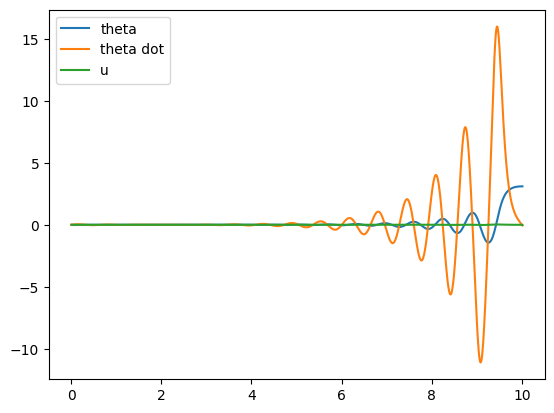

In [19]:
Tsim_es, Xsim_es, Usim_es = pendulum.simulate(
              t0=0.0,
              y0=[0.001, 0],
              tf=10.0,
              dt=0.01,
              controller=ilqr_controller,
              integrator="runge_kutta")
plot_timeseries(Tsim_es, Xsim_es, Usim_es)


# Export the data to csv file
simulation_csv_data_es = np.array([Tsim_es, np.asarray(Xsim_es).T[0], np.asarray(Xsim_es).T[1],Usim_es]).T
np.savetxt("es_simulation_data_es.csv", simulation_csv_data_es, delimiter=',', header="time,pos,vel,tau", comments="")
ilqr_controller.restart_trajectory()

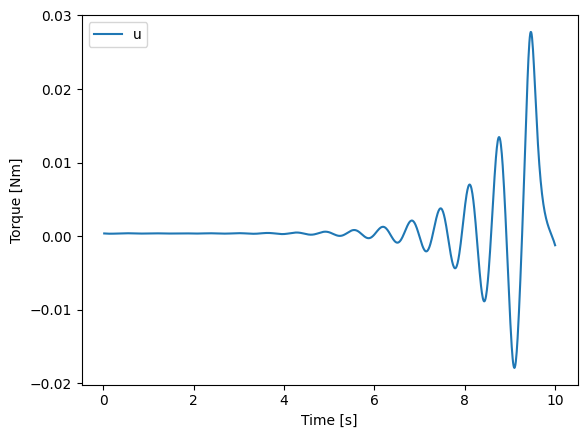

In [20]:
plt.plot(Tsim_es[1:-1], ilqr_controller.u_trj, label="u")
plt.ylabel("Torque [Nm]")
plt.xlabel("Time [s]")
plt.legend(loc="best")
plt.show()

## 3. iLQR MPC Controller for the simple pendulum

The previous version of the iLQR calculates the trajectory once and then will try to follow it. This can make it hard for the controller to respond to disturbances in an effective way. For the actual controller which will do that, we define a new class, **iLQR_MPC_Controller**. From **iLQR_MPC_Controller** we will run the optimization periodically and then have the motor output the first torque command of the calculated trajectory. As you know, this technique is known by the name of Receding Horizon Control.

In [21]:
class iLQR_MPC_Controller():
    import time

    def __init__(self, mass, length, damping, torque_limit, gravity, Kp, Kd, N, 
                 max_iter=100, regu_init=100, break_cost_redu=5e-1, 
                 init_u_trj=None, init_x_trj=None, n_x=2, n_u=1, dt=0.02):
        self.Kp = Kp
        self.Kd = Kd
        self.m = mass
        self.l = length
        self.g = gravity
        self.b = damping
        self.torque_limit = torque_limit
        self.N = N
        self.dt = dt
        self.i = 0
        self.iLQR = iLQR_Calculator(n_x = n_x, n_u = n_u)
        self.max_iter = max_iter
        self.break_cost_redu = break_cost_redu
        self.regu_init = regu_init
        self.init_u_trj = init_u_trj
        self.init_x_trj = init_x_trj
        self.x_trj_archive = np.array([]).reshape(0,self.N)
        self.u_trj_archive = np.array([]).reshape(0,self.N-1)
        self.cost_archive = []
        self.ite_archive = []

    def set_discrete_dynamics(self,dyn_func):
        self.iLQR.set_discrete_dynamics(dyn_func)

    def set_stage_cost(self,s_cost):
        self.iLQR.set_stage_cost(s_cost)

    def set_final_cost(self,f_cost):
        self.iLQR.set_final_cost(f_cost)

    def set_start(self, x0):
        self.iLQR.set_start(x0)

    def run_ilqr(self, N, init_u_trj, init_x_trj):
        self.iLQR.init_derivatives()
        self.x_trj, self.u_trj, self.cost_trace, self.regu_trace, self.redu_ratio_trace, self.redu_trace = self.iLQR.run_ilqr(self.N, self.init_u_trj, self.init_x_trj, self.max_iter, self.regu_init, self.break_cost_redu)
    
    def init_derivatives(self):
        self.iLQR.init_derivatives()
    
    def restart_trajectory(self):
        self.i = 0

    def set_current_state(self,x):
        self.xc = x

    def get_trajectory_history(self):
        return self.x_trj_archive

    def get_control_history(self):
        return self.u_trj_archive

    def get_cost_history(self):
        return self.cost_archive
        
    def get_ite_history(self):
        return self.ite_archive
        
    def get_animation_data(self):
        return self.get_trajectory_history(), self.get_control_history(), self.dt, self.N

    def get_control_output(self,x):
        #print(x)
        start = time.time()
        
        self.iLQR.set_start(np.array(x))
        self.x_trj, self.u_trj, self.cost_trace, self.regu_trace, self.redu_ratio_trace, self.redu_trace = self.iLQR.run_ilqr(self.N, self.init_u_trj,
                                                                                                                              None, True, self.max_iter, 
                                                                                                                              self.break_cost_redu, 
                                                                                                                              self.regu_init)[:6]
        tau = self.u_trj[0].item()
        self.init_u_trj = self.u_trj
        self.init_x_trj = self.x_trj
        
        self.x_trj_archive = np.vstack((self.x_trj_archive, np.asarray(self.x_trj).T))
        self.u_trj_archive = np.vstack((self.u_trj_archive, np.asarray(self.u_trj).T))
        self.cost_archive.append(self.cost_trace[0])
        self.ite_archive.append(len(self.cost_trace))

        print(f"solved after {time.time() - start} - input is {tau}")
        
        return np.clip(tau, -self.torque_limit, self.torque_limit)

### 3.1. Configuring the MPC iLQR controller

When seting up the iLQR controller, we must create an instance of the class **iLQR_MPC_Controller** with the dynamic properties of the pendulum, the maximum torque we will allow (symmetric), the control horizon, and settings for the optimization.

Then we add the dynamics equation and cost functions. We also set the initial state. For the MPC version of our iLQR we will use the following cost functions:

In [22]:
def pendulum_swingup_stage_cost_norm(x, u):
    goal=[np.pi, 0]
    #Cu= 0.6
    #Cp= 0.5
    #Cv= 0.2
    #Cen= 0.0
    #Cu= 1.5
    #Cp= 0.05
    #Cv= 0.025
    Cu= 1.0
    Cp= 0.5
    Cv= 0.325
    Cen= 0.1
    m=mass
    l=length
    b=damping
    cf=coulomb_fric
    g=gravity
    
    md = check_type(x)

    eps = 1e-6
    c_pos = ((x[0] - goal[0])/(2*goal[0]))**2.0 + eps
    c_vel = ((x[1] - goal[1])/15)**2.0 + eps
    c_control = (u[0]/0.03)**2.0 + eps
    en_g = 0.5*m*(l*goal[1])**2.0 + m*g*l*(1.0-md.cos(goal[0]))
    en = 0.5*m*(l*x[1])**2.0 + m*g*l*(1.0-md.cos(x[0]))
    c_en = ((en-en_g)/(m*g*l*(1.0-md.cos(np.pi))))**2.0 + eps
    return Cu*c_control + Cp*c_pos + Cv*c_vel + Cen*c_en

def pendulum_swingup_final_cost_norm(x):
    goal=[np.pi, 0]
    #Cp= 5.0
    #Cv= 2.0
    #Cen= 30.0
    Cp= 1.0
    Cv= 0.5
    Cen= 30.0
    m=mass
    l=length
    b=damping
    cf=coulomb_fric
    g=gravity
    
    md = check_type(x)

    eps = 1e-6
    c_pos = ((x[0] - goal[0])/(2*goal[0]))**2.0 + eps
    c_vel = ((x[1] - goal[1])/15)**2.0 + eps
    en_g = 0.5*m*(l*goal[1])**2.0 + m*g*l*(1.0-md.cos(goal[0]))
    en = 0.5*m*(l*x[1])**2.0 + m*g*l*(1.0-md.cos(x[0]))
    c_en = ((en-en_g)/(m*g*l*(1.0-md.cos(np.pi))))**2.0 + eps
    return Cp*c_pos + Cv*c_vel + Cen*c_en

### Think-Pair-Share (10 min)

Set the correct weights in functions *pendulum_swingup_stage_cost_norm* and *pendulum_swingup_final_cost_norm* to achieve a swing-up with as little torque as possible. Test the solution to make sure the MPC controller achieves the maneuver.

In [23]:
ilqr_MPC_controller = iLQR_MPC_Controller(mass=mass, length=length, damping = damping, torque_limit=0.03, gravity=gravity, Kp=0.1, Kd = 0.01, 
                                          N=50, max_iter=50, regu_init=100, break_cost_redu=5e-1, dt = 0.01)
ilqr_MPC_controller.set_discrete_dynamics(pendulum_discrete_dynamics_RK4)
ilqr_MPC_controller.set_stage_cost(pendulum_swingup_stage_cost_norm)
ilqr_MPC_controller.set_final_cost(pendulum_swingup_final_cost_norm)
ilqr_MPC_controller.init_derivatives()

x0 = np.array([0.001, 0.0])
ilqr_MPC_controller.set_start(x0)

### 3.2. iLQR Simulation

To check that our iLQR controller works as intended, we can simulate its output.

In [25]:
%%capture
T, X, U, anim = pendulum.simulate_and_animate(
              t0=0.0,
              y0=[0.001, 0.0], #y0=[0.001, 0.0],
              tf=10.0,
              dt=0.01,
              controller=ilqr_MPC_controller,
              integrator="runge_kutta")
ilqr_controller.restart_trajectory()

In [26]:
# HTML(anim.to_html5_video())

In [27]:
# plot_timeseries(T, X, U)

In [39]:
def plot_timeseries(T, X, U):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(T, np.asarray(X).T[0], label=r"\theta")
    plt.plot(T, np.asarray(X).T[0], label=r"\dot\theta")
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.plot(T, U, label="u_main")
    plt.legend(loc="best")
    plt.grid()

    plt.tight_layout()
    plt.show()

solved after 0.016232967376708984 - inptu is 0.0003985179680453114
solved after 0.015572071075439453 - inptu is 0.0006610222029053313
solved after 0.014577388763427734 - inptu is 0.0008599629312989526
solved after 0.014774560928344727 - inptu is 0.0010057968607551217
solved after 0.014932394027709961 - inptu is 0.001130674718218119
solved after 0.014277219772338867 - inptu is 0.0014097416921262968
solved after 0.014142990112304688 - inptu is 0.0016831314104780479
solved after 0.01469564437866211 - inptu is 0.001596008023403244
solved after 0.01937079429626465 - inptu is 0.0018745292104872218
solved after 0.021047353744506836 - inptu is 0.00214293907318226
solved after 0.016299009323120117 - inptu is 0.0023985915010509584
solved after 0.014519929885864258 - inptu is 0.0026389405112022387
solved after 0.014920949935913086 - inptu is 0.0028615650252652295
solved after 0.014710426330566406 - inptu is 0.003064192850440113
solved after 0.015899181365966797 - inptu is 0.003244723607224459
sol

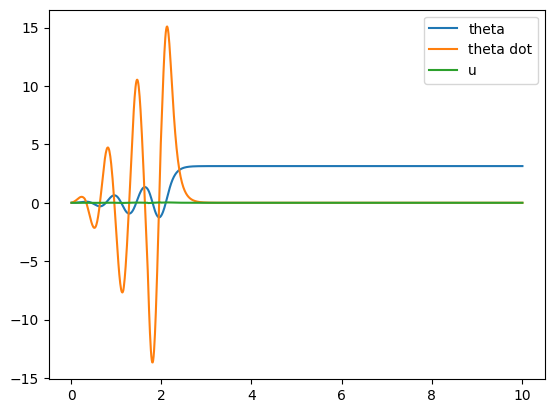

15.238113403320312


In [28]:
t1 = time.time()
Tsim_es, Xsim_es, Usim_es = pendulum.simulate(
              t0=0.0,
              y0=[0.001, 0.0],
              tf=10.0,
              dt=0.01,
              controller=ilqr_MPC_controller,
              integrator="runge_kutta")
plot_timeseries(Tsim_es, Xsim_es, Usim_es)
t2 = time.time()
print(t2-t1)

# Export the data to csv file
simulation_csv_data_es = np.array([Tsim_es, np.asarray(Xsim_es).T[0], np.asarray(Xsim_es).T[1],Usim_es]).T
np.savetxt("es_simulation_data_es.csv", simulation_csv_data_es, delimiter=',', header="time,pos,vel,tau", comments="")
ilqr_MPC_controller.restart_trajectory()

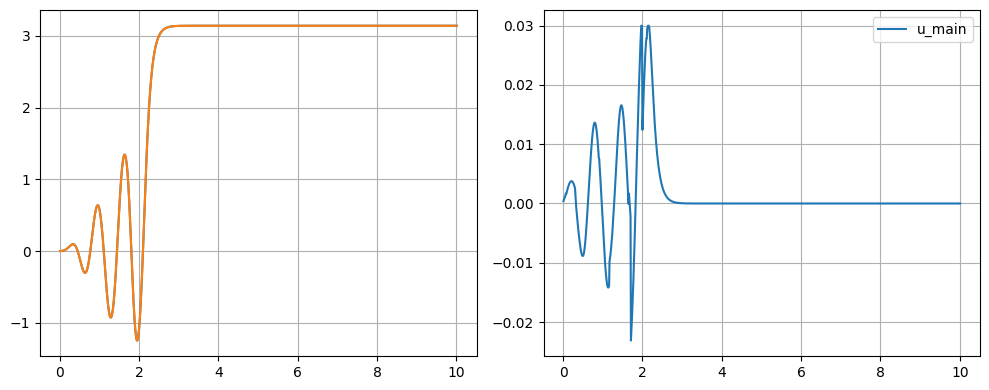

In [40]:
plot_timeseries(Tsim_es, np.array(Xsim_es), Usim_es)


In [31]:
Xsim_es

[array([0.00102822, 0.00563291]),
 array([0.00113416, 0.01552676]),
 array([0.00135456, 0.02850243]),
 array([0.00171511, 0.04353195]),
 array([0.00223382, 0.06010731]),
 array([0.00293811, 0.0806134 ]),
 array([0.00386572, 0.10472961]),
 array([0.00502152, 0.12621759]),
 array([0.00640862, 0.15094876]),
 array([0.00805732, 0.17849229]),
 array([0.00999328, 0.20834886]),
 array([0.01223682, 0.23995769]),
 array([0.01480241, 0.27270447]),
 array([0.01769813, 0.3059302 ]),
 array([0.0209253 , 0.33894082]),
 array([0.02447817, 0.37101746]),
 array([0.02834372, 0.40142714]),
 array([0.03250158, 0.42943394]),
 array([0.03692405, 0.45431031]),
 array([0.04157626, 0.47534852]),
 array([0.0464164 , 0.49187197]),
 array([0.05139612, 0.50324627]),
 array([0.05646096, 0.50888994]),
 array([0.06155098, 0.50828452]),
 array([0.0666014 , 0.50098404]),
 array([0.07154338, 0.48662362]),
 array([0.0763049, 0.4649271]),
 array([0.08081161, 0.43571362]),
 array([0.08498789, 0.39890308]),
 array([0.088757

In [ ]:
plt.plot(Tsim_es, np.asarray(Xsim_es).T[0], label="theta")
plt.plot(Tsim_es, Usim_es, label="u")
plt.show()

We can also visualize the trajectories that the controller generates everytime it provides a torque output. Run the cell below to generate an animation that shows some of the trajectories calculated during the previous simulation, as well as to plot the controller's output.

In [ ]:
pendulum.animate_MPC_plot2(ilqr_MPC_controller.get_trajectory_history(), np.asarray(ilqr_MPC_controller.get_control_history()), ilqr_MPC_controller.get_cost_history(), ilqr_MPC_controller.get_ite_history(), 0.01, 50, vid = True, vidname = "video_air1")

plt.plot(Tsim_es, Usim_es, label="u")
plt.xlabel("Time [s]")
plt.ylabel("Torque [Nm]")
plt.legend(loc="best")
plt.show()

# 4. Hardware Experiments on the CloudPendulum

The following image shows the CloudPendulum that you should already know by now. Now you get to apply our controller on the real hardware!

<center><img src="part1/media/pendulum_hardware.jpeg" width="400"></center>


### 4.1. Offline iLQR experiment

In [ ]:
with open(os.path.expanduser("~/.env"), 'r') as file:
    user_token = file.read().strip('\n')

In [ ]:
tf = 10 # Final time (s)
dt = 0.01 # Time step (s)

ilqr_controller.restart_trajectory()
Treal_es, Xreal_es, Ureal_es, Ureal_es_des, vod_filepath, vod_filepath = pendulum.run_on_hardware(user_token, tf, dt, controller=ilqr_controller, save_video=False) 

# Measured Position
plt.figure
plt.plot(Treal_es, np.asarray(Xreal_es).T[0])
plt.xlabel("Time (s)")
plt.ylabel("Position (rad)")
plt.title("Position (rad) vs Time (s)")
plt.show()

# Measured Velocity
plt.figure
plt.plot(Treal_es, np.asarray(Xreal_es).T[1])
plt.xlabel("Time (s)")
plt.ylabel("Velocity (rad/s)")
plt.title("Velocity (rad/s) vs Time (s)")
plt.show()

# Measured Torque
plt.figure
plt.plot(Treal_es, Ureal_es)
plt.plot(Treal_es, Ureal_es_des)
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.title("Torque (Nm) vs Time (s)")
plt.show()

## 4.2 iLQR MPC experiment

In [ ]:
tf = 10 # Final time (s)
dt = 0.01 # Time step (s)

ilqr_MPC_controller.restart_trajectory()
Treal_lqr, Xreal_lqr, Ureal_lqr, Ureal_lqr_des, video_url, video_path = pendulum.run_on_hardware(user_token, tf, dt, controller=ilqr_MPC_controller, save_video=False)

# Measured Position
plt.figure
plt.plot(Treal_lqr, np.asarray(Xreal_lqr).T[0])
plt.xlabel("Time (s)")
plt.ylabel("Position (rad)")
plt.title("Position (rad) vs Time (s)")
plt.show()

# Measured Velocity
plt.figure
plt.plot(Treal_lqr, np.asarray(Xreal_lqr).T[1])
plt.xlabel("Time (s)")
plt.ylabel("Velocity (rad/s)")
plt.title("Velocity (rad/s) vs Time (s)")
plt.show()

# Measured Torque
plt.figure
plt.plot(Treal_lqr, Ureal_lqr)
plt.plot(Treal_lqr, Ureal_lqr_des)
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.title("Torque (Nm) vs Time (s)")
plt.show()

In [ ]:
plt.plot(ilqr_MPC_controller.u_trj)